# ORANGE_CIRCLE Notebook 1 — Entraînement SegNet
**ISIC Project | Segmentation des Lésions Cutanées**

Ce notebook entraîne uniquement le modèle SegNet sur le dataset ISIC 2018.

## SETTING Étape 1 — Setup & Création des dossiers

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
from pathlib import Path

PROJECT_PATH = '/content/drive/MyDrive/ISIC_Project'
IMAGES_PATH  = os.path.join(PROJECT_PATH, 'data', 'Images')
MASQUES_PATH = os.path.join(PROJECT_PATH, 'data', 'Masques')
OUTPUTS_PATH = os.path.join(PROJECT_PATH, 'outputs')

# ── Dossier pour SegNet ────────────────────────────────────────────────────────
DIRS = {
    'segnet' : os.path.join(OUTPUTS_PATH, 'segnet'),
}
for name, path in DIRS.items():
    os.makedirs(path, exist_ok=True)

sys.path.append(os.path.join(PROJECT_PATH, 'src'))

print('OK Structure de dossiers créée :')
for name, path in DIRS.items():
    print(f'   FOLDER outputs/{name}/')

Mounted at /content/drive
OK Structure de dossiers créée :
   FOLDER outputs/segnet/


## PACKAGE Étape 2 — Installations & Imports

In [2]:
!pip install -q albumentations opencv-python-headless scikit-learn seaborn torchvision

import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models.segmentation as seg_models
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from tqdm import tqdm
import json, time, warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'OK Device : {device}')
if torch.cuda.is_available():
    print(f'   GPU  : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')

OK Device : cuda
   GPU  : Tesla T4
   VRAM : 14.6 GB


## CARD_INDEX Étape 3 — Dataset & DataLoaders

In [3]:
IMG_SIZE   = 256
BATCH_SIZE = 8
EPOCHS     = 30
THRESHOLD  = 0.5

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3), A.ColorJitter(p=0.4), A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

class ISICDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img  = cv2.cvtColor(cv2.imread(str(self.image_paths[idx])), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img  = out['image']; mask = out['mask'].unsqueeze(0)
        return img.float(), mask.float()

IMAGE_EXTENSIONS = {'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}
all_images = sorted([p for p in Path(IMAGES_PATH).glob('*.*') if p.suffix.lower() in IMAGE_EXTENSIONS])
all_masks  = sorted([p for p in Path(MASQUES_PATH).glob('*.*') if p.suffix.lower() in IMAGE_EXTENSIONS])
assert len(all_images) == len(all_masks)

train_imgs, temp_imgs, train_msks, temp_msks = train_test_split(
    all_images, all_masks, test_size=0.3, random_state=42)
val_imgs, test_imgs, val_msks, test_msks = train_test_split(
    temp_imgs, temp_msks, test_size=0.5, random_state=42)

train_loader = DataLoader(ISICDataset(train_imgs, train_msks, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(ISICDataset(val_imgs,   val_msks,   val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(ISICDataset(test_imgs,  test_msks,  val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'OK Dataset : {len(all_images)} images')
print(f'   Train:{len(train_imgs)} | Val:{len(val_imgs)} | Test:{len(test_imgs)}')

OK Dataset : 2594 images
   Train:1815 | Val:389 | Test:390


## BUILDING_CONSTRUCTION Étape 4 — Définition de SegNet

In [4]:
class SegNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n=2):
        super().__init__()
        layers = []
        for i in range(n):
            layers += [nn.Conv2d(in_ch if i==0 else out_ch, out_ch, 3, padding=1),
                       nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

class SegNet(nn.Module):
    """Encodeur VGG-like + décodeur par max-unpooling avec indices."""
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1 = SegNetBlock(in_channels,64,2); self.enc2 = SegNetBlock(64,128,2)
        self.enc3 = SegNetBlock(128,256,3);         self.enc4 = SegNetBlock(256,512,3)
        self.enc5 = SegNetBlock(512,512,3)
        self.dec5 = SegNetBlock(512,512,3); self.dec4 = SegNetBlock(512,256,3)
        self.dec3 = SegNetBlock(256,128,3); self.dec2 = SegNetBlock(128,64,2)
        self.dec1 = SegNetBlock(64,64,2)
        self.pool   = nn.MaxPool2d(2,2,return_indices=True)
        self.unpool = nn.MaxUnpool2d(2,2)
        self.final  = nn.Conv2d(64, out_channels, 1)
    def forward(self, x):
        x1=self.enc1(x); x,i1=self.pool(x1)
        x2=self.enc2(x); x,i2=self.pool(x2)
        x3=self.enc3(x); x,i3=self.pool(x3)
        x4=self.enc4(x); x,i4=self.pool(x4)
        x5=self.enc5(x); x,i5=self.pool(x5)
        x=self.unpool(x,i5,output_size=x5.size()); x=self.dec5(x)
        x=self.unpool(x,i4,output_size=x4.size()); x=self.dec4(x)
        x=self.unpool(x,i3,output_size=x3.size()); x=self.dec3(x)
        x=self.unpool(x,i2,output_size=x2.size()); x=self.dec2(x)
        x=self.unpool(x,i1,output_size=x1.size()); x=self.dec1(x)
        return self.final(x)

# ── Instanciation ─────────────────────────────────────
segnet = SegNet().to(device)

print(f'ORANGE_CIRCLE SegNet : {sum(p.numel() for p in segnet.parameters() if p.requires_grad):>12,} paramètres')

# Test forward
with torch.no_grad():
    d = torch.randn(2,3,IMG_SIZE,IMG_SIZE).to(device)
    print(f'OK SegNet output : {segnet(d).shape}')

ORANGE_CIRCLE SegNet :   24,943,361 paramètres
OK SegNet output : torch.Size([2, 1, 256, 256])


## TOOLS Étape 5 — Fonctions communes

In [5]:
# ── Perte ─────────────────────────────────────────────────────────────────────
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__(); self.bce = nn.BCEWithLogitsLoss()
    def dice_loss(self, pred, target, smooth=1e-6):
        pred  = torch.sigmoid(pred)
        inter = (pred * target).sum(dim=(2,3))
        union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
        return 1 - ((2*inter+smooth)/(union+smooth)).mean()
    def forward(self, pred, target):
        return 0.5*self.bce(pred,target) + 0.5*self.dice_loss(pred,target)

criterion = DiceBCELoss()

# ── Métriques ──────────────────────────────────────────────────────────────────
def compute_metrics(pred_logit, target, threshold=THRESHOLD, smooth=1e-6):
    pred_bin = (torch.sigmoid(pred_logit) > threshold).float()
    tp = (pred_bin * target).sum(dim=(2,3))
    tn = ((1-pred_bin)*(1-target)).sum(dim=(2,3))
    fp = (pred_bin*(1-target)).sum(dim=(2,3))
    fn = ((1-pred_bin)*target).sum(dim=(2,3))
    total = tp+tn+fp+fn
    return {
        'accuracy'  : ((tp+tn)/(total+smooth)).mean().item(),
        'dice'      : ((2*tp+smooth)/(2*tp+fp+fn+smooth)).mean().item(),
        'iou'       : ((tp+smooth)/(tp+fp+fn+smooth)).mean().item(),
        'precision' : ((tp+smooth)/(tp+fp+smooth)).mean().item(),
        'recall'    : ((tp+smooth)/(tp+fn+smooth)).mean().item(),
    }

# ── Checkpoint ─────────────────────────────────────────────────────────────────
def save_ckpt(epoch, model, opt, sch, history, best_dice, path):
    torch.save({'epoch':epoch,'model_state':model.state_dict(),
                'optim_state':opt.state_dict(),'sched_state':sch.state_dict(),
                'history':history,'best_dice':best_dice}, path)

def load_ckpt(path, model, opt, sch):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    opt.load_state_dict(ckpt['optim_state'])
    sch.load_state_dict(ckpt['sched_state'])
    return ckpt['epoch'], ckpt['history'], ckpt['best_dice']

print('OK DiceBCELoss, compute_metrics, save/load_ckpt prêts !')

OK DiceBCELoss, compute_metrics, save/load_ckpt prêts !


## LAUNCH Étape 6 — Fonction d'entraînement

In [6]:
def train_model(model, model_name, lr=1e-4, epochs=EPOCHS):
    """
    Entraîne un modèle et sauvegarde TOUT dans son propre dossier.

    Dossier : outputs/<model_name>/
    Fichiers créés :
      - checkpoint_<model_name>.pth  → reprise automatique si coupure
      - best_<model_name>.pth        → meilleur modèle (Dice Val)
      - training_curves_<model_name>.png
      - metrics_<model_name>.json
    """
    model_dir   = DIRS[model_name]
    ckpt_path   = os.path.join(model_dir, f'checkpoint_{model_name}.pth')
    best_path   = os.path.join(model_dir, f'best_{model_name}.pth')
    curves_path = os.path.join(model_dir, f'training_curves_{model_name}.png')
    metrics_path= os.path.join(model_dir, f'metrics_{model_name}.json')

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    # ── Reprise automatique ───────────────────────────────────────────────────
    if os.path.exists(ckpt_path):
        start_epoch, history, best_dice = load_ckpt(ckpt_path, model, optimizer, scheduler)
        start_epoch += 1
        print(f'REFRESH [{model_name}] Reprise epoch {start_epoch}/{epochs} '
              f'(best Dice: {best_dice:.4f})')
    else:
        start_epoch = 1; best_dice = 0.0
        history = {k:[] for k in ['train_loss','val_loss','train_dice','val_dice',
                                   'train_acc','val_acc','train_iou','val_iou',
                                   'train_prec','val_prec','train_rec','val_rec']}
        print(f'NEW_BUTTON [{model_name}] Démarrage — {epochs} epochs | lr={lr}')
        print(f'   FOLDER Dossier : outputs/{model_name}/')

    t0 = time.time()

    for epoch in range(start_epoch, epochs+1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        tr = {k:0.0 for k in ['loss','dice','acc','iou','prec','rec']}
        for imgs, masks in tqdm(train_loader,
                                 desc=f'[{model_name}] {epoch}/{epochs} Train',
                                 leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            preds = model(imgs)
            loss  = criterion(preds, masks)
            loss.backward(); optimizer.step()
            m = compute_metrics(preds, masks)
            tr['loss']+=loss.item(); tr['dice']+=m['dice']; tr['acc']+=m['accuracy']
            tr['iou'] +=m['iou'];   tr['prec']+=m['precision']; tr['rec']+=m['recall']
        for k in tr: tr[k] /= len(train_loader)

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        vl = {k:0.0 for k in ['loss','dice','acc','iou','prec','rec']}
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                preds = model(imgs)
                m = compute_metrics(preds, masks)
                vl['loss']+=criterion(preds,masks).item(); vl['dice']+=m['dice']
                vl['acc'] +=m['accuracy'];  vl['iou'] +=m['iou']
                vl['prec']+=m['precision']; vl['rec'] +=m['recall']
        for k in vl: vl[k] /= len(val_loader)

        scheduler.step(vl['loss'])

        # ── Historique ────────────────────────────────────────────────────────
        for k,v in [('train_loss',tr['loss']),('val_loss',vl['loss']),
                    ('train_dice',tr['dice']),('val_dice',vl['dice']),
                    ('train_acc', tr['acc']), ('val_acc', vl['acc']),
                    ('train_iou', tr['iou']), ('val_iou', vl['iou']),
                    ('train_prec',tr['prec']),('val_prec',vl['prec']),
                    ('train_rec', tr['rec']), ('val_rec', vl['rec'])]:
            history[k].append(v)

        # ── Checkpoint toutes les epochs → dossier du modèle ──────────────────
        save_ckpt(epoch, model, optimizer, scheduler, history, best_dice, ckpt_path)

        # ── Meilleur modèle → dossier du modèle ───────────────────────────────
        tag = ''
        if vl['dice'] > best_dice:
            best_dice = vl['dice']
            torch.save(model.state_dict(), best_path)
            save_ckpt(epoch, model, optimizer, scheduler, history, best_dice, ckpt_path)
            tag = ' UP_ARROW BEST'

        print(f'[{model_name}] Ep {epoch:02d}/{epochs} '
              f'| Loss {tr["loss"]:.4f}/{vl["loss"]:.4f} '
              f'| Dice {tr["dice"]:.4f}/{vl["dice"]:.4f} '
              f'| Acc {tr["acc"]:.4f}/{vl["acc"]:.4f}{tag}')

    elapsed = (time.time()-t0)/60

    # ── Courbes d'apprentissage → dossier du modèle ───────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history['train_loss'], label='Train', color='royalblue')
    axes[0].plot(history['val_loss'],   label='Val',   color='tomato')
    axes[0].set_title(f'[{model_name}] Perte'); axes[0].legend(); axes[0].grid(True,alpha=0.3)

    axes[1].plot(history['train_dice'], label='Train', color='royalblue')
    axes[1].plot(history['val_dice'],   label='Val',   color='tomato')
    axes[1].set_title(f'[{model_name}] Dice Score'); axes[1].legend(); axes[1].grid(True,alpha=0.3)

    axes[2].plot(history['train_acc'],  label='Train WARNING', color='royalblue', linestyle='--')
    axes[2].plot(history['val_acc'],    label='Val WARNING',   color='tomato',    linestyle='--')
    axes[2].set_title(f'[{model_name}] Accuracy (WARNING trompeuse)')
    axes[2].legend(); axes[2].grid(True,alpha=0.3)

    plt.suptitle(f'{model_name} — Courbes d\'apprentissage', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(curves_path, dpi=150, bbox_inches='tight')
    plt.show()

    # ── Métriques JSON → dossier du modèle ────────────────────────────────────
    metrics_summary = {
        'model'       : model_name,
        'best_dice_val': best_dice,
        'epochs_done' : epoch,
        'time_min'    : round(elapsed, 1),
        'final_train' : {k.replace('train_',''):history[k][-1] for k in history if k.startswith('train_')},
        'final_val'   : {k.replace('val_','')  :history[k][-1] for k in history if k.startswith('val_')},
        'history'     : history,
    }
    with open(metrics_path, 'w') as f:
        json.dump(metrics_summary, f, indent=2)

    print(f'\nOK [{model_name}] Terminé en {elapsed:.1f} min | Best Dice: {best_dice:.4f}')
    print(f'   FOLDER Fichiers dans outputs/{model_name}/ :')
    for fname in os.listdir(model_dir):
        sz = os.path.getsize(os.path.join(model_dir,fname))/1024
        print(f'      FILE {fname} ({sz:.0f} KB)')

    return history

print('OK train_model prête — sauvegarde dans le dossier du modèle !')

OK train_model prête — sauvegarde dans le dossier du modèle !


## ORANGE_CIRCLE Entraîner SegNet → `outputs/segnet/`

REFRESH [segnet] Reprise epoch 27/30 (best Dice: 0.8571)


[segnet] Ep 27/30 | Loss 0.1685/0.1671 | Dice 0.8495/0.8580 | Acc 0.9442/0.9441 UP_ARROW BEST


[segnet] Ep 28/30 | Loss 0.1673/0.1625 | Dice 0.8540/0.8565 | Acc 0.9442/0.9427


[segnet] Ep 29/30 | Loss 0.1643/0.1619 | Dice 0.8565/0.8592 | Acc 0.9449/0.9441 UP_ARROW BEST


[segnet] Ep 30/30 | Loss 0.1588/0.1703 | Dice 0.8595/0.8459 | Acc 0.9469/0.9394


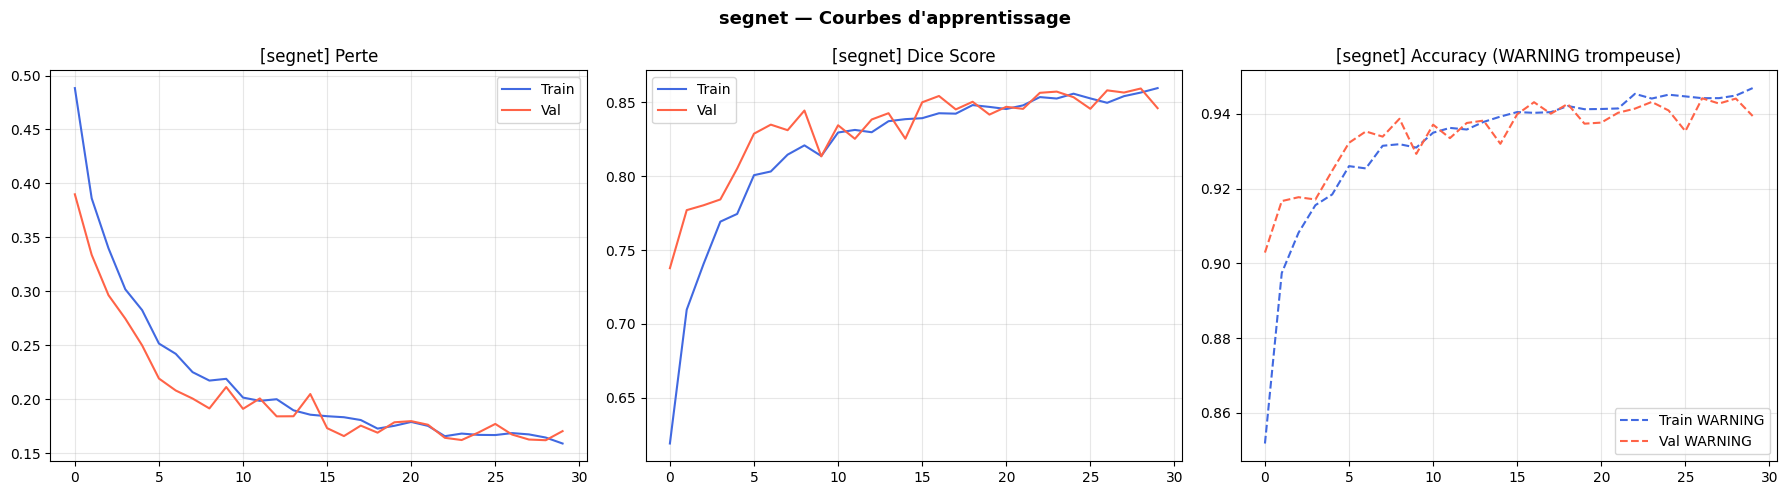


OK [segnet] Terminé en 48.7 min | Best Dice: 0.8592
   FOLDER Fichiers dans outputs/segnet/ :
      FILE best_segnet.pth (97551 KB)
      FILE checkpoint_segnet.pth (292518 KB)
      FILE training_curves_segnet.png (145 KB)
      FILE metrics_segnet.json (10 KB)


In [7]:
history_segnet = train_model(segnet, 'segnet', lr=1e-4, epochs=EPOCHS)

## REPORT Évaluation sur le Test Set

In [8]:
def evaluate_model(model, model_name):
    """Charge le meilleur modèle depuis son dossier et évalue sur le test set."""
    best_path = os.path.join(DIRS[model_name], f'best_{model_name}.pth')
    if os.path.exists(best_path):
        model.load_state_dict(torch.load(best_path, map_location=device))
        print(f'OK [{model_name}] Chargé depuis outputs/{model_name}/best_{model_name}.pth')
    else:
        print(f'WARNING  [{model_name}] Pas de checkpoint — utilise les poids actuels')

    model.eval()
    all_m = {k:[] for k in ['accuracy','dice','iou','precision','recall']}
    with torch.no_grad():
        for imgs, masks in tqdm(test_loader, desc=f'Test {model_name}', leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            m = compute_metrics(model(imgs), masks)
            for k in all_m: all_m[k].append(m[k])
    return {k: float(np.mean(v)) for k,v in all_m.items()}

# ── Évaluation de SegNet ──────────────────────────────────────────────────
print('REPORT Évaluation sur le jeu de TEST...\n')
results = evaluate_model(segnet, 'segnet')

# ── Tableau récapitulatif ─────────────────────────────────────────────────────
print()
print('='*50)
print(f'  {"Modèle":<13} {"Accuracy":>10} {"Dice STAR":>10} {"IoU":>10} {"Précision":>10} {"Recall":>10}')
print('='*50)
print(f'  {"SegNet":<13} {results["accuracy"]:>10.4f} {results["dice"]:>10.4f} '
      f'{results["iou"]:>10.4f} {results["precision"]:>10.4f} {results["recall"]:>10.4f}')
print('='*50)
print('  WARNING  Accuracy gonflée par déséquilibre — Dice Score = métrique principale')

REPORT Évaluation sur le jeu de TEST...

OK [segnet] Chargé depuis outputs/segnet/best_segnet.pth



  Modèle          Accuracy  Dice STAR        IoU  Précision     Recall
  SegNet            0.9454     0.8575     0.7762     0.8815     0.8832
  WARNING  Accuracy gonflée par déséquilibre — Dice Score = métrique principale


## OK Conclusion

In [9]:
print('='*50)
print('TROPHY  RÉSULTATS SEGNET')
print('='*50)
print(f'  Dice      : {results["dice"]:.4f}')
print(f'  IoU       : {results["iou"]:.4f}')
print(f'  Précision : {results["precision"]:.4f}')
print(f'  Recall    : {results["recall"]:.4f}')
print(f'  Accuracy  : {results["accuracy"]:.4f} WARNING')
print('='*50)

# Export conclusion
conclusion = {
    'model': 'SegNet',
    'results': results,
    'dataset': {'total':len(all_images),'train':len(train_imgs),
                'val':len(val_imgs),'test':len(test_imgs)},
    'config': {'epochs':EPOCHS,'batch_size':BATCH_SIZE,
               'img_size':IMG_SIZE,'threshold':THRESHOLD}
}
with open(os.path.join(DIRS['segnet'],'conclusion_segnet.json'),'w') as f:
    json.dump(conclusion, f, indent=2, default=float)
print('SAVE outputs/segnet/conclusion_segnet.json')

TROPHY  RÉSULTATS SEGNET
  Dice      : 0.8575
  IoU       : 0.7762
  Précision : 0.8815
  Recall    : 0.8832
  Accuracy  : 0.9454 WARNING
SAVE outputs/segnet/conclusion_segnet.json
